In [1]:
import os
import sys
sys.path.append(os.path.expandvars('$HOME/software/simple_adl'))
import glob
import yaml
import time
from IPython.core.debugger import set_trace
import math
import numpy as np
import pandas as pd
from pandas import *
from scipy import stats
from scipy.optimize import curve_fit

import healpy as hp
import fitsio as fits

import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import LogNorm
#plt.rcParams.update({"text.usetex": True, "font.family": "serif"})
import seaborn as sns

from astropy import units as u
from astropy.coordinates import SkyCoord

import simple_adl.survey
import simple_adl.isochrone
from simple_adl.coordinate_tools import distanceModulusToDistance, angsep
from simple_adl.search import write_output, search_by_distance, cut_isochrone_path

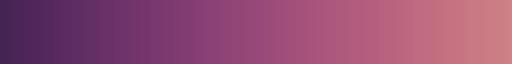

In [16]:
#cmap = sns.cubehelix_palette(start=1.0, rot=-1.0, light=0.8, dark=0.2, hue=1.0, reverse=True, as_cmap=True)
cmap = sns.cubehelix_palette(start=3.0, rot=0.5, light=0.6, dark=0.2, hue=1.0, reverse=True, as_cmap=True)
#cmap = sns.cubehelix_palette(start=0.0, rot=0.0, light=0.7, dark=0.3, hue=1.0, reverse=True, as_cmap=True)
#cmap = sns.cubehelix_palette(start=0.5, rot=0.0, light=0.7, dark=0.3, hue=1.0, reverse=True, as_cmap=True)

cmap

## Functions

In [17]:
def gnomic(mu_ra, mu_dec, ra, dec):
    """
    https://mathworld.wolfram.com/GnomonicProjection.html
    The Gnomic projection is a conformal (angle-preserving) map of 
    coordinates on a sphere to coordinates on a plane around some central
    coordinate.
    """
    mu_ra = np.deg2rad(mu_ra)
    mu_dec = np.deg2rad(mu_dec)
    ra = np.deg2rad(ra)
    dec = np.deg2rad(dec)
    
    cos_c = np.sin(mu_dec) * np.sin(dec) + np.cos(mu_dec) * np.cos(dec) * np.sin(ra - mu_ra)
    x = np.cos(dec) * np.sin(ra - mu_ra) / cos_c
    y = (np.cos(mu_dec) * np.sin(dec) - np.sin(mu_dec) *np.cos(dec) * np.cos(ra - mu_ra)) / cos_c
    
    return x, y

In [18]:
def plot_region(name, data, axs, fig, cmap):

    hb = axs.hexbin(data['ra'], data['dec'], mincnt=1, cmap=cmap, gridsize=50)
    cb = fig.colorbar(hb, ax=axs)
    axs.set_title(f'{name}')
    axs.set_xlabel(r'$ra$')
    axs.set_ylabel(r'$dec$')
    
    return

In [19]:
def plots(position, cmap, real_data=None, sim_data=None, merged_data=None):
    
    if (real_data is not None) and (sim_data is not None):
        fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(24, 6))
        plot_region("DC2", real_data, axs[0], fig, cmap)
        plot_region(f'Simulated Satellite {mcid}', sim_data, axs[1], fig, cmap)
        plot_region('Merged', merged_data, axs[2], fig, cmap)
        plot_cmd(merged_data, axs[3])
        plt.show()
    else:
        fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))
        plot_region("DC2", real_data, axs[0], fig, cmap)
        plot_cmd(real_data, axs[1])
        plt.show()
        
    return

In [20]:
def calc_survey(dist,survey='foo'):
    if survey == 'des':
        #    Dist   A0     Mv0    logr0
        P0=[[11.3 ,  21.5,   7.8 ,   3.8],
            [22.6 ,  24.1,   8.3 ,   4.2],
            [45.2 ,  17.2,   5.2 ,   4.3], #tuned
            [90.5 ,  8.6 ,   1.2 ,   4.1],
            [181.0,  6.6 ,   -1.1,   4.1],
            [362.0,  6.3 ,   -2.3,   4.3]]
        #P0=[[11.3 ,  23.1 ,  8.1  ,  3.9  ],
        #    [22.6 ,  19.9 ,  7.3  ,  4.1  ],
        #    [45.2 ,  21.1 ,  6.1  ,  4.5  ],
        #    [90.5 ,  8.8  ,  1.2  ,  4.1  ],
        #    [181.0,  7.9  ,  -0.7 ,  4.2  ],
        #    [362.0,  6.4  ,  -2.2 ,  4.3  ]]
    elif survey == 'ps1':
        #    Dist      A0     Mv0    logr0
        P0=[[11.3 ,  21.7,   6.7 ,   3.9],
            [22.6 ,  16.4,   4.3 ,   4.0],
            [45.2 ,  11.5,   1.0 ,   4.0],
            [90.5 ,  8.6 ,   -1.0,   4.0],
            [181.0,  7.2 ,   -2.4,   4.2],
            [362.0,  4.2 ,   -4.8,   4.0]]
        P0=[[11.3 ,  22.8 ,  7.1  ,  4.0],
            [22.6 ,  19.0 ,  5.0  ,  4.1],
            [45.2 ,  14.1 ,  1.8  ,  4.2],
            [90.5 ,  11.0 ,  -0.3 ,  4.3],
            [181.0,  7.5  ,  -2.2 ,  4.2],
            [362.0,  6.8  ,  -4.0 ,  4.4],]
    elif survey == 'foo':
        P0=[[11.3 ,  22.7 ,  10.0 ,  4.0  ],
            [22.6 ,  24.8 ,  10.0 ,  4.3  ],
            [45.2 ,  1.4  ,  1.2  ,  3.5  ],
            [90.5 ,  0.0  ,  -1.3 ,  3.5  ],
            [181.0,  0.0  ,  -2.0 ,  3.5  ],
            [362.0,  0.0  ,  -3.1 ,  3.5  ],]


    #A = normalization factor (how curved)
    #B = Mv0 -- the absolute magnitude cut
    #C = R0  -- the r_physical cut
    PARAMS = np.rec.fromrecords(P0,names=['D','A','B','C'])

    a = np.interp(dist,PARAMS['D'],PARAMS['A'])
    b = np.interp(dist,PARAMS['D'],PARAMS['B'])
    c  = np.interp(dist,PARAMS['D'],PARAMS['C'])

    abs_mag = np.linspace(mbins.min(),mbins.max(),1000)
    r_physical = a/(abs_mag - b) + c

    return abs_mag, r_physical, a, b, c

In [21]:
def setdefaults(kwargs,defaults):
    for k,v in defaults.items():
        kwargs.setdefault(k,v)
    return kwargs

In [22]:
def draw_survey(dist,survey,**kwargs):
    defaults = dict(ls='--',color='k',zorder=1)
    kwargs = setdefaults(kwargs,defaults)
    abs_mag, r_physical,a,b,c = calc_survey(dist,survey)
    sel = abs_mag < b
    plt.plot(abs_mag[sel],r_physical[sel],**kwargs)

In [23]:
def query(service, ra, dec, radius=1.0, gmax=23.5):
    """ Return data queried from Rubin TAP
    
    Parameters
    ----------
    service: str 
        TAP service
    ra: float
        Right Ascension [deg]
    dec: float 
        Declination [deg]
    radius: float
        Radius around (ra, dec) [deg]

    Returns
    -------
    good_results: DataFrame
    """

    # Redenning coefficients
    # R_g = 3.185
    # R_r = 2.140
    # R_i = 1.571   # I can't find any reference for these old values 

    # Reddening coefficients from Table 6 of Schlafly & Finkbeiner (2011)
    R_g = 3.237
    R_r = 2.273 
    R_i = 1.684 

    # Define our reference position on the sky and E(B-V) at that position using SFD reddening maps
    coord = SkyCoord(ra=ra*u.degree, dec=dec*u.degree, frame='icrs')
    E_BV = sfd(coord)
    radius = radius * u.deg

    A_g = R_g*E_BV
    A_r = R_r*E_BV
    A_i = R_i*E_BV
    
    # Quality selection and star--galaxy separation adapted from
    # https://github.com/LSSTDESC/DC2-analysis/blob/master/tutorials/object_pandas_stellar_locus.ipynb

    snr_threshold = 5
    mag_err_threshold = 1/snr_threshold
    mag_threshold =26

    # assuming extendedness is the same in all bands we assume g_extendedness matches extendedness for dp0.2 tables
    
    safe_max_extended = 1.0
    
    query = f"""
        SELECT
            coord_ra AS ra, coord_dec AS dec,
            scisql_nanojanskyToAbMag(g_cModelFlux) AS mag_g,
            scisql_nanojanskyToAbMag(r_cModelFlux) AS mag_r,
            scisql_nanojanskyToAbMagSigma(g_cModelFlux, g_cModelFluxErr) AS magerr_g, 
            scisql_nanojanskyToAbMagSigma(r_cModelFlux, r_cModelFluxErr) AS magerr_r,
            scisql_nanojanskyToAbMag(g_cModelFlux) - {A_g} AS mag_corrected_g,
            scisql_nanojanskyToAbMag(r_cModelFlux) - {A_r} AS mag_corrected_r,
            g_extendedness
        FROM dp02_dc2_catalogs.Object
        WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec), CIRCLE('ICRS', {coord.ra.value}, {coord.dec.value}, {radius.value})) = 1
        AND g_extendedness < {str(safe_max_extended)}
    """
    
    job = service.submit_job(query)
    job.run()
    job.wait(phases=['COMPLETED', 'ERROR'])
    async_results = job.fetch_result()
    results = async_results.to_table().to_pandas()
    job.delete()

    good_snr = (results['magerr_g'] < mag_err_threshold) & (results['magerr_r'] < mag_err_threshold)
    good_results = results[good_snr]
    
    return good_results

In [24]:
# Note that this query (which uses the truth information about star--galaxy separation) is much slower
def query_RSP_truth(service, ra, dec, radius=1):
    """ Return data queried from Rubin TAP using true star-galaxy separation
    Parameters
    ----------
    service: str 
        TAP service
    ra: float
        Right Ascension [deg]
    dec: float 
        Declination [deg]
    radius: float
        Radius around (ra, dec) [deg]

    Returns
    -------
    df: DataFrame
        Data from Rubin TAP
    """
    # Redenning coefficients
    # R_g = 3.185
    # R_r = 2.140
    # R_i = 1.571   # I can't find any reference for these old values 

    # Reddening coefficients from Table 6 of Schlafly & Finkbeiner (2011)
    R_g = 3.237
    R_r = 2.273 
    R_i = 1.684 

    # Define our reference position on the sky and E(B-V) at that position using SFD reddening maps
    coord = SkyCoord(ra=ra*u.degree, dec=dec*u.degree, frame='icrs')
    E_BV = sfd(coord)
    radius = radius * u.deg

    A_g = R_g*E_BV
    A_r = R_r*E_BV
    A_i = R_i*E_BV
    
    query = f"""
        SELECT
            coord_ra AS ra, coord_dec AS dec,
            scisql_nanojanskyToAbMag(g_cModelFlux) AS mag_g,
            scisql_nanojanskyToAbMag(r_cModelFlux) AS mag_r,
            scisql_nanojanskyToAbMagSigma(g_cModelFlux, g_cModelFluxErr) AS magerr_g, 
            scisql_nanojanskyToAbMagSigma(r_cModelFlux, r_cModelFluxErr) AS magerr_r,
            scisql_nanojanskyToAbMag(g_cModelFlux) - {A_g} AS mag_corrected_g,
            scisql_nanojanskyToAbMag(r_cModelFlux) - {A_r} AS mag_corrected_r,
            g_extendedness AS extended_class
        FROM dp02_dc2_catalogs.Object as obj
        JOIN dp02_dc2_catalogs.MatchesTruth as truth
        ON truth.match_objectId = obj.objectId
        WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec), CIRCLE('ICRS', {coord.ra.value}, {coord.dec.value}, {radius.value})) = 1
        AND truth.match_objectId >= 0 
        AND truth.match_candidate = 1
        AND truth.truth_type = 2
    """
    df = service.search(query).to_table().to_pandas()
    df['MC_SOURCE_ID'] = 0
    
    return df

In [25]:
def get_catalog_file(catalog_dir, mc_source_id):
    """
    Inputs:
        catalog_dir = string corresponding to directory containing the stellar catalog infiles
        mc_source_id = integer corresponding the target MC_SOURCE_ID value
    Outputs:
        catalog_infile = string corresponding to filename of stellar catalog containing mc_source_id
    """
    catalog_infiles = sorted(glob.glob(catalog_dir + '/*catalog*.fits'))
    mc_source_id_array = []
    catalog_infile_index_array = []
    for ii, catalog_infile in enumerate(catalog_infiles):
        mc_source_id_min = int(os.path.basename(catalog_infile).split('.')[0].split('mc_source_id_')[-1].split('-')[0])
        mc_source_id_max = int(os.path.basename(catalog_infile).split('.')[0].split('mc_source_id_')[-1].split('-')[1])
        assert (mc_source_id_max > mc_source_id_min) & (mc_source_id_min >= 1), 'Found invalue MC_SOURCE_ID values in filenames'
        mc_source_id_array.append(np.arange(mc_source_id_min, mc_source_id_max + 1))
        catalog_infile_index_array.append(np.tile(ii, 1 + (mc_source_id_max - mc_source_id_min)))

    mc_source_id_array = np.concatenate(mc_source_id_array)
    catalog_infile_index_array = np.concatenate(catalog_infile_index_array)

    assert len(mc_source_id_array) == len(np.unique(mc_source_id_array)), 'Found non-unique MC_SOURCE_ID values in filenames'
    assert np.in1d(mc_source_id, mc_source_id_array), 'Requested MC_SOURCE_ID value not among files'
    mc_source_id_index = np.nonzero(mc_source_id == mc_source_id_array)[0][0] # second [0] added by smau 7/23/18 to fix incompatiable type bug
    return catalog_infiles[catalog_infile_index_array[mc_source_id_index]]

In [26]:
def load_sim_data(sim_dir, mc_source_id):
    """
    Load info for injecting satellite sims
    """
    cat_file = get_catalog_file(sim_dir, mc_source_id)
    cat_fits = fits.FITS(cat_file)
    w = cat_fits[1].where(f'MC_SOURCE_ID == {mc_source_id}')
    try:       
        data = cat_fits[1][w]
        cat_fits.close()
        return data
    except IndexError: 
        print('Array is empty')
        
    return

In [27]:
def plot_cmd(data, axs):
    """Plot a color magnitude diagram.
    
    data: DataFrame with photometry data
    """
    y = data['mag_g']  
    x = data['mag_g'] - data['mag_r']
    
    xlims = [-1, 1.5]  #need to find better way to restrict axes
    ylims = [16,28]
    axs.set_xlim(xlims); 
    axs.set_ylim(ylims); 
    
    axs.set_ylabel('$Magnitude (g)$')
    axs.set_xlabel('$Color (g-r)$')
    
    axs.plot(x, y, 'ko', markersize=0.3, alpha=0.3)
    axs.invert_yaxis()

    
    #plt.show()
    
    return

In [40]:
def plot_cmd_sep(rdata, sdata, axs):
    """ Plots a color magnitude diagram with simulated satellite objects highlighted.

    Inputs:
        rdata: DataFrame
            Background field photometry data
        sdata: DataFrame
            Simulated satellite photometry data
        axs: pyplot axes object
    """
    y = rdata['mag_g']  
    x = rdata['mag_g'] - rdata['mag_r']
    
    xlims = [-0.5, 1]
    ylims = [16,27]
    axs.set_xlim(xlims); 
    axs.set_ylim(ylims); 
    
    axs.set_ylabel('$g$')
    axs.set_xlabel('$g-r$')
    
    n, x, y, p = axs.hist2d(x, y, cmap='Greys', bins=[np.linspace(-0.5, 1, 50), np.linspace(16, 27, 50)], label='DC2 object', norm=LogNorm(vmax=1000))
    plt.colorbar(p, label='Number of objects')
    y = sdata['mag_g']  
    x = sdata['mag_g'] - sdata['mag_r']
    axs.plot(x, y, 'o', color='red',  markersize=5, alpha=1, label='satellite star', markeredgecolor='white', mew=0.5, rasterized=True)
    axs.invert_yaxis()
    axs.legend(markerscale=1)
    
    plt.show()
    
    return

In [39]:
def plot_cmd_sep_iso(data, iso_selection, axs):
    """ Plots a color magnitude diagram, highlighting objects that pass isochrone selection.

    Inputs:
        data (pd.DataFrame): photometry data
        iso_selection: isochrone to be applied to the data
        axs: pyplot axes object
    """
    source = data[iso_selection]
    data = data[~iso_selection]
    y = data['mag_g']  
    x = data['mag_g'] - data['mag_r']
    
    xlims = [-0.5, 1]
    ylims = [16,27]
    axs.set_xlim(xlims); 
    axs.set_ylim(ylims); 
    
    axs.set_ylabel('$g$')
    axs.set_xlabel('$g-r$')
    
    n, x, y, p = axs.hist2d(x, y, cmap='Greys', bins=[np.linspace(-0.5, 1, 50), np.linspace(16, 27, 50)], label='DC2 object', norm=LogNorm(vmax=1000))
    plt.colorbar(p, label='Number of objects')
    y = source['mag_g']  
    x = source['mag_g'] - source['mag_r']
    axs.plot(x, y, 'o', color='red',  markersize=3, alpha=1, label='isochrone object', markeredgecolor='white', mew=0.5, rasterized=True)
    axs.invert_yaxis()
    axs.legend(markerscale=1)
    
    plt.show()
    
    return

In [29]:
def randomize_coordinates_within_circle(df, center_ra, center_dec, radius):
    num_rows = df.shape[0]
    
    # Convert degrees to radians
    center_ra_rad = np.radians(center_ra)
    center_dec_rad = np.radians(center_dec)
    
    r = radius*np.sqrt(np.random.uniform(size=num_rows))
    thetas = math.pi*2*np.random.uniform(size=num_rows)
    
    random_ra = center_ra + r * np.cos(thetas)
    random_dec = center_dec + r * np.sin(thetas)
    
    # Update the DataFrame with the randomized coordinates
    df.insert(loc=0, column='ra', value=random_ra)
    df.insert(loc=1, column='dec', value=random_dec)
    
    return

In [32]:
def load_simdf(catalog_dir: str, results_dir: str) -> pd.DataFrame:
    """
    Combines information from the sim catalog files and the results directory to build the sims dataframe for results plots.
    
    parameters:
        catalog_dir: directory with the sim catalogs
        results_dir: directory with sim search results 
        
    returns:
        sims: sims dataframe
    """
    population_file = glob.glob(os.path.join(catalog_dir, '*population*'))
    files = glob.glob(os.path.join(results_dir, '*.csv'))
    first_file = files[0]
    sim_pop = fits.read(population_file[0])
    sim_pop = sim_pop.byteswap().newbyteorder() 
    df1 = pd.DataFrame(sim_pop)
    file_ids = [files[8:23] for files in os.listdir(results_dir) if 'ipynb' not in files]
    for i,f in enumerate(population_file):
        if i == 0:
            continue
        for ids in file_ids:
            if ids in f:
                sim_pop = fits.read(f)
                sim_pop = sim_pop.byteswap().newbyteorder()
                df2 = pd.DataFrame(sim_pop)
                df1 = pd.concat((df1,df2), ignore_index=True)
                break

    datadf = pd.read_csv(first_file)
    for f in files:
        if f == first_file:
            continue
        df3 = pd.read_csv(f)
        datadf = pd.concat((datadf, df3), ignore_index=True)

    sims = pd.merge(df1,datadf[['MC_SOURCE_ID','SIG']],on='MC_SOURCE_ID',how='left')
    sims.set_index('MC_SOURCE_ID', inplace=True)
    sims = sims[sims['FRACDET_CORE'] == 1]
    sims = sims[sims['FRACDET_WIDE'] == 1]
    sims = sims[sims['FRACDET_HALF'] == 1]
    sims.loc[sims.DIFFICULTY == 2, 'SIG'] = 37.5
    
    return sims

## main

In [31]:
from lsst.rsp import get_tap_service

service = get_tap_service()
assert service is not None
assert service.baseurl == "https://data.lsst.cloud/api/tap"

/tmp/ipykernel_8466/4062763552.py:3: DeprecationWarning: get_tap_service() is deprecated, use get_tap_service("tap")
  service = get_tap_service()


In [18]:
sim_dir = '/project/shared/data/satsim/lsst_dc2_v6' 
population_file = glob.glob(os.path.join(sim_dir, '*population*'))

### background test

In [19]:
regions = sorted(glob.glob('v6_regions/region*'))
df = pd.DataFrame(columns=['center_ra', 'center_dec', 'sig', 'shuffled sig', 'delta sig'])
regions_df = pd.DataFrame(columns=['SIG', 'RA', 'DEC', 'MODULUS', 'R', 'N_OBS', 'N_OBS_HALF', 'N_MODEL'])
with open('config.yaml') as ymlfile:
    cfg = yaml.load(ymlfile, Loader=yaml.SafeLoader)
    survey = simple_adl.survey.Survey(cfg)

radius = 2
for i, reg in enumerate(regions):
    region_df = read_csv(reg)
    region_df.drop(columns=['Unnamed: 0'], inplace=True)
    good_snr = (region_df['magerr_g'] < 0.2) & (region_df['magerr_r'] < 0.2)
    region_df = region_df[good_snr]
    good_mag = (region_df['mag_g'] < survey.catalog['mag_max']) & (region_df['mag_r'] < survey.catalog['mag_max'])
    region_df = region_df[good_mag]
    ra = region_df['center_ra'].values[0]
    dec = region_df['center_dec'].values[0]
    
    shuffled = region_df.drop(['ra', 'dec'], axis=1, inplace=False)     # create the randomized circle of objects
    randomize_coordinates_within_circle(shuffled, ra, dec, radius)

    region = simple_adl.survey.Region(survey, ra, dec)
    region.data = region_df

    # Scan in distance moduli    
    distance_modulus = np.random.uniform(16, 24)
    iso_search = simple_adl.isochrone.Isochrone(survey=survey.isochrone['survey'],
                                           band_1=survey.band_1.lower(),
                                           band_2=survey.band_2.lower(),
                                           age=12.0, #survey.isochrone['age'],
                                           metallicity=0.00010, #survey.isochrone['metallicity'],
                                           distance_modulus=distance_modulus)

    iso_selection = cut_isochrone_path(region.data[survey.mag_dered_1], 
                                          region.data[survey.mag_dered_2],
                                          region.data[survey.mag_err_1],
                                          region.data[survey.mag_err_2],
                                          iso_search,
                                          survey.catalog['mag_max'],
                                          radius=0.1)

    results = search_by_distance(survey, region, distance_modulus, iso_selection) 
    ra_peak_array, dec_peak_array, r_peak_array, sig_peak_array, distance_modulus_array, n_obs_peak_array, n_obs_half_peak_array, n_model_peak_array = np.asarray(results)
    best_ra_peak, best_dec_peak, best_r_peak, best_distance_modulus, n_obs_peak, n_obs_half_peak, n_model_peak, best_sig_peak = 0, 0, 0, 0, 0, 0, 0, 0
    if len(sig_peak_array) == 0:
        continue
    # Sort peaks according to significance
    index_sort = np.argsort(sig_peak_array)[::-1]
    ra_peak_array = ra_peak_array[index_sort]
    dec_peak_array = dec_peak_array[index_sort]
    r_peak_array = r_peak_array[index_sort]
    sig_peak_array = sig_peak_array[index_sort]
    distance_modulus_array = distance_modulus_array[index_sort]
    n_obs_peak_array = n_obs_peak_array[index_sort]
    n_obs_half_peak_array = n_obs_half_peak_array[index_sort]
    n_model_peak_array = n_model_peak_array[index_sort]

    # Collect overlapping peaks
    for ii in range(0, len(sig_peak_array)):
        if sig_peak_array[ii] < 0:
            continue
        sep = angsep(ra_peak_array[ii], dec_peak_array[ii], ra_peak_array, dec_peak_array)
        sig_peak_array[(sep < r_peak_array[ii]) & (np.arange(len(sig_peak_array)) > ii)] = -1.

    # Prune the list of peaks
    ra_peak_array = ra_peak_array[sig_peak_array > 0.]
    dec_peak_array = dec_peak_array[sig_peak_array > 0.]
    r_peak_array = r_peak_array[sig_peak_array > 0.]
    distance_modulus_array = distance_modulus_array[sig_peak_array > 0.]
    n_obs_peak_array = n_obs_peak_array[sig_peak_array > 0.]
    n_obs_half_peak_array = n_obs_half_peak_array[sig_peak_array > 0.]
    n_model_peak_array = n_model_peak_array[sig_peak_array > 0.]
    sig_peak_array = sig_peak_array[sig_peak_array > 0.] # Update the sig_peak_array last!

    if sig_peak_array[0] > best_sig_peak:
        best_sig_peak = sig_peak_array[0]
        best_ra_peak = ra_peak_array[0]
        best_dec_peak = dec_peak_array[0]
        best_r_peak = r_peak_array[0]
        best_distance_modulus = distance_modulus_array[0]
        n_obs_peak = n_obs_peak_array[0]
        n_obs_half_peak = n_obs_half_peak_array[0]
        n_model_peak = n_model_peak_array[0]
        
    sig = best_sig_peak

    df0 = pd.DataFrame([[best_sig_peak, best_ra_peak, best_dec_peak, best_r_peak, best_distance_modulus, n_obs_peak, n_obs_half_peak, n_model_peak]], columns=regions_df.columns)
    regions_df = pd.concat([regions_df, df0], ignore_index=True)

    region = simple_adl.survey.Region(survey, ra, dec)
    region.data = shuffled

    iso_search = simple_adl.isochrone.Isochrone(survey=survey.isochrone['survey'],
                                           band_1=survey.band_1.lower(),
                                           band_2=survey.band_2.lower(),
                                           age=12.0, #survey.isochrone['age'],
                                           metallicity=0.00010, #survey.isochrone['metallicity'],
                                           distance_modulus=distance_modulus)

    iso_selection = cut_isochrone_path(region.data[survey.mag_dered_1], 
                                          region.data[survey.mag_dered_2],
                                          region.data[survey.mag_err_1],
                                          region.data[survey.mag_err_2],
                                          iso_search,
                                          survey.catalog['mag_max'],
                                          radius=0.1)

    results = search_by_distance(survey, region, distance_modulus, iso_selection) 
    ra_peak_array, dec_peak_array, r_peak_array, sig_peak_array, distance_modulus_array, n_obs_peak_array, n_obs_half_peak_array, n_model_peak_array = np.asarray(results)
    best_ra_peak, best_dec_peak, best_r_peak, best_distance_modulus, n_obs_peak, n_obs_half_peak, n_model_peak, best_sig_peak = 0, 0, 0, 0, 0, 0, 0, 0

    # Sort peaks according to significance
    index_sort = np.argsort(sig_peak_array)[::-1]
    ra_peak_array = ra_peak_array[index_sort]
    dec_peak_array = dec_peak_array[index_sort]
    r_peak_array = r_peak_array[index_sort]
    sig_peak_array = sig_peak_array[index_sort]
    distance_modulus_array = distance_modulus_array[index_sort]
    n_obs_peak_array = n_obs_peak_array[index_sort]
    n_obs_half_peak_array = n_obs_half_peak_array[index_sort]
    n_model_peak_array = n_model_peak_array[index_sort]

    # Collect overlapping peaks
    for ii in range(0, len(sig_peak_array)):
        if sig_peak_array[ii] < 0:
            continue
        sep = angsep(ra_peak_array[ii], dec_peak_array[ii], ra_peak_array, dec_peak_array)
        sig_peak_array[(sep < r_peak_array[ii]) & (np.arange(len(sig_peak_array)) > ii)] = -1.

    # Prune the list of peaks
    ra_peak_array = ra_peak_array[sig_peak_array > 0.]
    dec_peak_array = dec_peak_array[sig_peak_array > 0.]
    r_peak_array = r_peak_array[sig_peak_array > 0.]
    distance_modulus_array = distance_modulus_array[sig_peak_array > 0.]
    n_obs_peak_array = n_obs_peak_array[sig_peak_array > 0.]
    n_obs_half_peak_array = n_obs_half_peak_array[sig_peak_array > 0.]
    n_model_peak_array = n_model_peak_array[sig_peak_array > 0.]
    sig_peak_array = sig_peak_array[sig_peak_array > 0.] # Update the sig_peak_array last!

    if sig_peak_array[0] > best_sig_peak:
        best_sig_peak = sig_peak_array[0]

    shuf_sig = best_sig_peak
    delta = sig - shuf_sig
    df1 = pd.DataFrame([[ra, dec, sig, shuf_sig, delta]], columns=df.columns)
    df = pd.concat([df, df1], ignore_index=True)
    
regions_df.to_csv("v6_regions/results/regions.csv")
df.to_csv("background_test_df.csv")

/opt/lsst/software/stack/conda/envs/lsst-scipipe-9.0.0/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/lsst/software/stack/conda/envs/lsst-scipipe-9.0.0/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Characteristic density = 2600.0 deg^-2
Fitting aperture to hotspot...
Characteristic density local = 2775.3 deg^-2 = 0.771 arcmin^-2
Candidate: x_peak:       -1.025, y_peak:       -0.315, r_peak:        0.020, sig:        3.093, ra_peak:       53.905, dec_peak:      -38.955
Fitting aperture to hotspot...
Characteristic density local = 2644.0 deg^-2 = 0.734 arcmin^-2
Candidate: x_peak:       -0.305, y_peak:       -0.185, r_peak:        0.040, sig:        3.227, ra_peak:       54.832, dec_peak:      -38.832
Fitting aperture to hotspot...
Characteristic density local = 2618.1 deg^-2 = 0.727 arcmin^-2
Candidate: x_peak:       -0.305, y_peak:       -0.015, r_peak:        0.040, sig:        3.483, ra_peak:       54.833, dec_peak:      -38.662
Fitting aperture to hotspot...
Characteristic density local = 2644.0 deg^-2 = 0.734 arcmin^-2
Candidate: x_peak:       -0.245, y_peak:        0.265, r_peak:        0.050, sig:        3.328, ra_peak:       54.911, dec_peak:      -38.382
Fitting aperture 

/tmp/ipykernel_712/3844512798.py:88: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  regions_df = pd.concat([regions_df, df0], ignore_index=True)


Characteristic density = 3400.0 deg^-2
Fitting aperture to hotspot...
Characteristic density local = 3596.9 deg^-2 = 0.999 arcmin^-2
Candidate: x_peak:       -0.995, y_peak:        0.515, r_peak:        0.060, sig:        3.596, ra_peak:       53.959, dec_peak:      -38.126
Fitting aperture to hotspot...
Characteristic density local = 3425.8 deg^-2 = 0.952 arcmin^-2
Candidate: x_peak:       -0.695, y_peak:        0.005, r_peak:        0.030, sig:        4.025, ra_peak:       54.334, dec_peak:      -38.639
Fitting aperture to hotspot...
Characteristic density local = 3533.2 deg^-2 = 0.981 arcmin^-2
Candidate: x_peak:       -0.575, y_peak:        0.045, r_peak:        0.030, sig:        3.910, ra_peak:       54.488, dec_peak:      -38.600
Fitting aperture to hotspot...
Characteristic density local = 3481.5 deg^-2 = 0.967 arcmin^-2
Candidate: x_peak:       -0.345, y_peak:        0.905, r_peak:        0.020, sig:        3.554, ra_peak:       54.787, dec_peak:      -37.742
Fitting aperture 

/tmp/ipykernel_712/3844512798.py:146: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, df1], ignore_index=True)
/opt/lsst/software/stack/conda/envs/lsst-scipipe-9.0.0/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/lsst/software/stack/conda/envs/lsst-scipipe-9.0.0/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Characteristic density = 1400.0 deg^-2
Fitting aperture to hotspot...
Characteristic density local = 1466.2 deg^-2 = 0.407 arcmin^-2
Candidate: x_peak:       -1.305, y_peak:        0.325, r_peak:        0.040, sig:        2.659, ra_peak:       53.953, dec_peak:      -33.187
Fitting aperture to hotspot...
Characteristic density local = 1356.8 deg^-2 = 0.377 arcmin^-2
Candidate: x_peak:       -0.865, y_peak:        1.095, r_peak:        0.030, sig:        3.220, ra_peak:       54.488, dec_peak:      -32.423
Fitting aperture to hotspot...
Characteristic density local = 1400.0 deg^-2 = 0.389 arcmin^-2
Candidate: x_peak:       -0.845, y_peak:        1.735, r_peak:        0.040, sig:        3.364, ra_peak:       54.519, dec_peak:      -31.783
Fitting aperture to hotspot...
Characteristic density local = 1420.5 deg^-2 = 0.395 arcmin^-2
Candidate: x_peak:       -0.775, y_peak:        0.225, r_peak:        0.050, sig:        2.787, ra_peak:       54.586, dec_peak:      -33.294
Fitting aperture 

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [59]:
regions_df.to_csv("v7_regions/results/regions.csv")

In [60]:
v7_regs = regions_df.head(1700)
dets = v7_regs[v7_regs['SIG'] > 5.5]
len(dets)/len(v7_regs)

0.022941176470588236

In [89]:
v6_regs = pd.read_csv('v6_regions/results/regions.csv')
v6_regs = v6_regs.head(1700)
v6_regs

,Unnamed: 0,SIG,RA,DEC,MODULUS,R,N_OBS,N_OBS_HALF,N_MODEL
0,0,3.766497,55.346259,-39.232694,0.09,22.571825,81.0,25.0,52.194375
1,1,4.061481,55.247790,-31.906710,0.19,18.665602,170.0,55.0,122.965625
2,2,6.342653,50.442278,-39.798786,0.04,18.567553,29.0,6.0,7.037168
3,3,5.396893,49.926930,-42.919323,0.05,17.652200,34.0,8.0,11.780972
4,4,3.905534,55.951924,-31.884142,0.05,19.800075,28.0,7.0,12.515625
...,...,...,...,...,...,...,...,...,...
1695,1695,5.779989,68.969918,-37.048161,0.28,21.845476,768.0,184.0,619.360000
1696,1696,7.856855,72.685011,-36.341233,0.10,22.590060,148.0,49.0,72.256631
1697,1697,4.473531,56.672299,-28.527531,0.03,21.573564,23.0,6.0,8.015625
1698,1698,4.074189,57.193201,-35.778420,0.04,16.826681,21.0,5.0,7.800000


In [81]:
v6_regs['MODULUS'].values

array([0.09, 0.19, 0.04, ..., 0.03, 0.04, 0.29])

In [95]:
near = v6_regs[v6_regs['R'] > 20.5]
ndetected = near[near['SIG'] > 5.5]
len(ndetected)/len(near)

0.29045092838196285

In [69]:
detected = v6_regs[v6_regs['SIG'] > 8.4]
len(detected)/len(v6_regs)

0.02176470588235294

In [18]:
df1 = pd.read_csv('background_test_df.csv')
df2 = pd.read_csv('background_test2_df.csv')
print(len(df1))
print(len(df2))

5030
4582


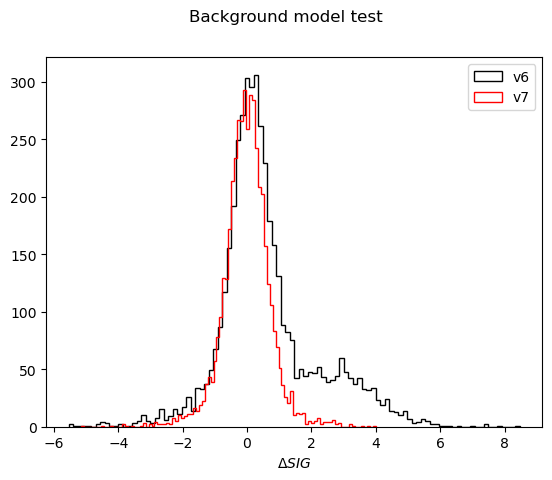

In [20]:
df1 = pd.read_csv('background_test_df.csv')
df2 = pd.read_csv('background_test2_df.csv')
df1 = df1[:4500]
df2 = df2[:4500]

fig, axs = plt.subplots(1,1)
fig.suptitle('Background model test')

axs.hist(df1['delta sig'], bins=100, histtype='step', color='black', label='v6')
axs.hist(df2['delta sig'], bins=100, histtype='step', color='red', label='v7')

axs.set_xlabel(r'$\Delta SIG$')
plt.legend()
plt.savefig('background model test4.pdf')
plt.savefig('background model test4.jpg')
plt.show()

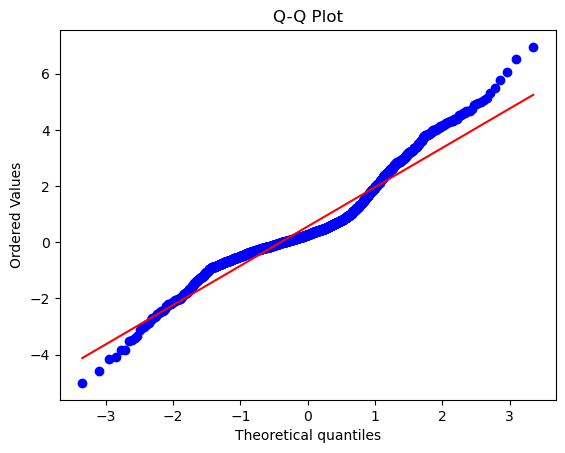

In [50]:
from scipy.stats import probplot

# Q-Q plot
probplot(df2['delta sig'], dist='norm', plot=plt)
plt.title('Q-Q Plot')
plt.show()

### results plots

In [66]:
#setting up sim dataframe

catalog_dir = '/project/shared/data/satsim/lsst_dc2_v7' 
results_dir = 'results_dir/07_sims_v7_final_mag_cut'
simsv7 = load_simdf(catalog_dir, results_dir)

catalog_dir = '/project/shared/data/satsim/lsst_dc2_v6' 
results_dir = 'results_dir/sims_v6_final_mag_cut'
simsv6 = load_simdf(catalog_dir, results_dir)

In [73]:
print('v7: ', len(simsv7))
simsv7 = simsv7[simsv7['SIG'] < 5.5]
print('v7: ', len(simsv7))

print('v6: ', len(simsv6))
simsv6 = simsv6[simsv6['SIG'] < 5.5]
print('v6: ', len(simsv6))

v7:  21498
v7:  21498
v6:  78973
v6:  20152


In [72]:
print('v6: ', len(simsv6))
df0 = simsv6[simsv6['SIG'] < 5.97]
print('v6: ', len(df0))

v6:  78973
v6:  21519


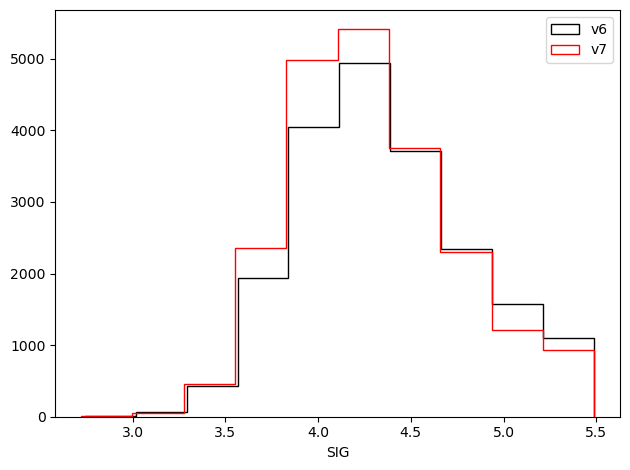

In [75]:
fig, axs = plt.subplots(1, 1)
axs.set_xlabel("SIG")
axs.hist(simsv6['SIG'], histtype='step', color='black', label='v6')
axs.hist(simsv7['SIG'], histtype='step', color='red', label='v7')
plt.tight_layout()
plt.legend()
plt.savefig('sig_hists.jpeg')

### star galaxy efficiency plots

In [ ]:
# Note that this query (which uses the truth information about star--galaxy separation) is much slower
def custom_query(service, ra=56.860588, dec = -41.548298, radius=1):
    """Return data queried from Rubin TAP using true star-galaxy separation
    Parameters
    ----------
    service : TAP service [str]
    ra      : Right Ascension [deg]
    dec     : Declination [deg]
    radius  : radius around (ra, dec) [deg]

    Returns
    -------
    df (pd.Dataframe): data from Rubin TAP
    """

    coord = SkyCoord(ra=ra*u.degree, dec=dec*u.degree, frame='icrs')
    radius = radius * u.deg
    snr_threshold = 5
    mag_err_threshold = 1/snr_threshold
    
    query = f"""
        SELECT
            obj.ra, obj.dec,
            obj.mag_g, obj.mag_r,
            obj.magerr_g, obj.magerr_r,
            obj.mag_g as mag_corrected_g, obj.mag_r as mag_corrected_r,
            obj.extendedness as extended_class
        FROM dp01_dc2_catalogs.object as obj
        JOIN dp01_dc2_catalogs.truth_match as truth
        ON truth.match_objectId = obj.objectId
        WHERE CONTAINS(POINT('ICRS', obj.ra, obj.dec),CIRCLE('ICRS', {coord.ra.value}, {coord.dec.value}, {radius.value})) = 1
        AND truth.match_objectId >= 0 
        AND truth.is_good_match = 1
        AND obj.extendedness < 1
        AND truth.truth_type = 2
    """
    
    results = service.search(query).to_table().to_pandas()

    good_snr = (results['magerr_g'] < mag_err_threshold) & (results['magerr_r'] < mag_err_threshold)
    good_results = results[good_snr]
    
    return good_results

In [ ]:
match_stars_class = custom_query(service)
match_stars_class

### For generating contours

In [ ]:
def func(x,a,b,c):
    return a/(x - b) + c

In [ ]:
# Initial guess
P0=[[11.3 ,  10.0 ,  4.0  ],
    [22.6 ,  10.0 ,  4.3  ],
    [45.2 ,  6.0  ,  4.3  ],
    [90.5 ,  4.7  ,  4.3  ],
    [181.0,  2.1  ,  4.3  ],
    [362.0,  -0.7 ,  4.6  ],]

BOUNDS = [[0, -10, 3.5], #lower bounds for each column
          [512, 10, 5.0]] #upper bounds for each column

files = sorted(glob.glob('lsst_measured_p50_d*.npy'))
results = []

for i,f in enumerate(files):
    dist = float(f.rsplit('_')[-1].rsplit('.',1)[0].strip('d'))
    data = np.load(f)
    sigma = 0.05*np.ones(len(data[:,1]))
    sigma[0] = 0.5
    sigma[-1] = 0.5
    #print sigma
    r = curve_fit(func,data[:,0],data[:,1],p0=P0[i],sigma=sigma,bounds=BOUNDS)
    results += [[dist]+r[0].tolist()]

results = np.asarray(results)
results = results[np.argsort(results[:,0])]

print('%-5s  %-5s  %-5s  %-5s'%('Dist','A0','Mv0','logr0'))
for r in results:
    print('[%-5.1f,  %-5.1f,  %-5.1f,  %-5.1f],'%tuple(r))

### looking for example sim

In [56]:
def celToGal(ra, dec):
    """
    Converts Celestial J2000 (deg) to Galactic (deg) coordinates
    """
    dec = np.radians(dec)
    sin_dec = np.sin(dec)
    cos_dec = np.cos(dec)

    ra = np.radians(ra)    
    ra_gp = np.radians(192.85948)
    de_gp = np.radians(27.12825)

    sin_ra_gp = np.sin(ra - ra_gp)
    cos_ra_gp = np.cos(ra - ra_gp)

    lcp = np.radians(122.932)    
    sin_b = (np.sin(de_gp) * sin_dec) \
            + (np.cos(de_gp) * cos_dec * cos_ra_gp)
    lcpml = np.arctan2(cos_dec * sin_ra_gp,
                          (np.cos(de_gp) * sin_dec) \
                          - (np.sin(de_gp) * cos_dec * cos_ra_gp))
    bb = np.arcsin(sin_b)
    ll = (lcp - lcpml + (2. * np.pi)) % (2. * np.pi)
    return np.degrees(ll), np.degrees(bb)

In [76]:
sim_dir = '/project/shared/data/satsim/lsst_dc2_v7'
sims = load_simdf(sim_dir, 'results_dir/07_sims_v7_final_mag_cut')

In [83]:
simsdf = sims[sims['DISTANCE'] > 64]
simsdf = simsdf[simsdf['ABS_MAG'] > 0]

simsdf = simsdf[simsdf['SIG'] > 5.5]
simsdf = simsdf[simsdf['SIG'] < 6.5]
l, b = celToGal(sims['RA'], sims['DEC'])
simsdf['l'] = l
simsdf['b'] = b
simsdf = simsdf[np.abs(simsdf['b']) < 44]
print(len(simsdf))

86


In [84]:
cols = simsdf.columns.tolist()
new_order = [cols[-3], cols[-2], cols[-1]] + cols[:-1]
simsdf = simsdf[new_order]

In [85]:
simsdf[:10]

,SIG,l,b,RA,DEC,DISTANCE,DISTANCE_MODULUS,STELLAR_MASS,R_PHYSICAL,N_G22,...,DENSITY,FRACDET_HALF,FRACDET_CORE,FRACDET_WIDE,MAGLIM_G,MAGLIM_R,EBV,SURVEY,SIG,l
MC_SOURCE_ID,,,,,,,,,,,,,,,,,,,,,
82212,5.52,227.124069,-42.757408,66.599358,-28.019789,285.456085,22.277697,11.135333,0.266666,0,...,0.000083,1.0,1.0,1.0,27.033026,26.867662,0.032498,lsst_dp0,5.52,227.124069
58770,5.51,248.958984,-40.019840,72.215820,-43.955517,81.304672,19.550577,11.097508,0.013263,0,...,0.000083,1.0,1.0,1.0,27.065796,26.907837,0.009810,lsst_dp0,5.51,248.958984
23121,5.87,247.901123,-43.317001,67.669991,-43.152416,65.719177,19.088461,56.157871,0.046745,0,...,0.000083,1.0,1.0,1.0,27.039324,26.866880,0.021390,lsst_dp0,5.87,247.901123
23831,5.93,230.805008,-41.698555,68.406410,-30.482172,111.993240,20.245958,56.852890,0.008050,0,...,0.000083,1.0,1.0,1.0,26.953794,26.828056,0.027065,lsst_dp0,5.93,230.805008
57911,6.21,246.923264,-39.994469,72.189133,-42.396156,83.564873,19.610119,19.830584,0.004483,0,...,0.000083,1.0,1.0,1.0,26.909744,26.792545,0.013673,lsst_dp0,6.21,246.923264
52465,5.86,233.343475,-42.464424,67.890831,-32.467751,326.688538,22.570669,10.158740,0.229603,0,...,0.000083,1.0,1.0,1.0,26.947412,26.839737,0.019365,lsst_dp0,5.86,233.343475
10903,5.99,228.699005,-40.863846,68.985832,-28.765390,76.670944,19.423155,31.216585,0.009972,0,...,0.000083,1.0,1.0,1.0,27.016317,26.913778,0.033780,lsst_dp0,5.99,228.699005
10947,5.68,228.829773,-43.341671,66.231026,-29.357889,178.343506,21.256287,54.406540,0.004931,0,...,0.000083,1.0,1.0,1.0,26.874624,26.850311,0.044557,lsst_dp0,5.68,228.829773
73043,5.61,233.679367,-41.076309,69.562599,-32.498432,410.484619,23.066484,154.115982,0.001194,0,...,0.000083,1.0,1.0,1.0,26.886631,26.793839,0.026692,lsst_dp0,5.61,233.679367


In [50]:
def load_and_merge(sim_id, truth_matching=True):
    """ Create merged dataframe and display CMDs using true information or observational information

    Parameters
    ----------
    sim_id: int
        The ID for the sim to plot
    truth_matching: bool
        Flag to use true or measured star-galaxy separation

    """
    file_start = str((sim_id//100)*100 + 1).zfill(7)
    file_end = str((sim_id//100)*100 + 100).zfill(7)
    sims_batch = file_start + '-' + file_end
    
    if truth_matching: 
        sim_dir = '/project/shared/data/satsim/lsst_dc2_v7/'
        file = sim_dir + 'sim_population_lsst_dc2_v7_mc_source_id_' + sims_batch + '.fits'
    else: 
        sim_dir = '/project/shared/data/satsim/lsst_dc2_v6/'
        file = sim_dir + 'sim_population_lsst_dc2_v6_mc_source_id_' + sims_batch + '.fits'
        
    print(sims_batch)
    
    with open('config.yaml') as ymlfile:
        cfg = yaml.load(ymlfile, Loader=yaml.SafeLoader)
        survey = simple_adl.survey.Survey(cfg)
    
    sim_population = fits.read(file)
    sim_positions = np.unique(sim_population[['RA', 'DEC']])
    sim_population  = sim_population.byteswap().newbyteorder()    # resetting byte order for compatibility
    sim_population = sim_population[sim_population['FRACDET_CORE'] == 1]
    sim_population = sim_population[sim_population['FRACDET_WIDE'] == 1]
    sim_population = sim_population[sim_population['FRACDET_HALF'] == 1]
    radius = 2
    
    for iii,position in enumerate(sim_positions):
        sim_population_at_position = sim_population[sim_population[['RA', 'DEC']] == position]
        t = pd.DataFrame(sim_population_at_position)
        
        if len(t['MC_SOURCE_ID'].values) == 0:
            print(f'No sims at {position}')
            continue
        elif sim_id not in t['MC_SOURCE_ID'].values:
            continue
            
        print(f'Querying region {position}')
        if truth_matching:
            real_data = query_RSP_truth(service, position[0], position[1], radius)
        else:
            real_data = query(service, position[0], position[1], radius)    # takes significantly longer due to galaxy contamination
    
        print('Satellites at ', position, ':\n', t['MC_SOURCE_ID'].values)
        for mcid in sim_population_at_position['MC_SOURCE_ID']:
            if mcid == sim_id:
                sim_data = load_sim_data(sim_dir, mcid)
                if sim_data is not None:
                    sim_data = sim_data.byteswap().newbyteorder()   # resetting byte order for compatibility
                    sim_data = pd.DataFrame(sim_data)
                    # mask to ensure we only use sims within the queried data's footprint
    
                    c2 = SkyCoord(sim_data['ra'], sim_data['dec'], unit='deg', frame='icrs')
                    center = SkyCoord(position[0], position[1], unit='deg')
                    d2d = center.separation(c2) 
                    catalogmsk = d2d < radius*u.deg
                    sim_data = sim_data[catalogmsk]
    
                    if sim_data.empty:
                        print(f'No sim data to inject into region at ({position[0]},{position[1]}) after applying mask')
                        continue
    
                    # merging the sims and dc2 data
                    frames = [real_data[real_data.columns[:-1]], sim_data[real_data.columns[:-1]]]
                    merged_data = pd.concat(frames)  # pd.Dataframe
                    # perform mag cut on the merged data
                    good_snr = (merged_data['magerr_g'] < 0.2) & (merged_data['magerr_r'] < 0.2)
                    merged_data = merged_data[good_snr]
                    good_mag = (merged_data['mag_g'] < survey.catalog['mag_max']) & (merged_data['mag_r'] < survey.catalog['mag_max'])
                    merged_data = merged_data[good_mag]
                    ra = position[0]
                    dec = position[1]
                    region = simple_adl.survey.Region(survey, ra, dec)
                    region.data = merged_data
    
                    # Scan in distance moduli    
                    distance_modulus = t.loc[t['MC_SOURCE_ID'] == mcid]['DISTANCE_MODULUS']
                    distance_modulus = distance_modulus.values[0]
                    iso_search = simple_adl.isochrone.Isochrone(survey=survey.isochrone['survey'],
                                                           band_1=survey.band_1.lower(),
                                                           band_2=survey.band_2.lower(),
                                                           age=12.0,
                                                           metallicity=0.00010,
                                                           distance_modulus=distance_modulus)
    
                    iso_selection = cut_isochrone_path(region.data[survey.mag_dered_1], 
                                                          region.data[survey.mag_dered_2],
                                                          region.data[survey.mag_err_1],
                                                          region.data[survey.mag_err_2],
                                                          iso_search,
                                                          survey.catalog['mag_max'],
                                                          radius=0.1)
                    # fig, axs = plt.subplots(1, 1)
                    # plot_cmd_sep_iso(merged_data, iso_selection, axs)
                    # fig, axs = plt.subplots(1, 1)
                    # plot_cmd_sep(real_data, sim_data, axs)
                    results = search_by_distance(survey, region, distance_modulus, iso_selection) 
                    ra_peak_array, dec_peak_array, r_peak_array, sig_peak_array, distance_modulus_array, n_obs_peak_array, n_obs_half_peak_array, n_model_peak_array = np.asarray(results)
                    best_ra_peak, best_dec_peak, best_r_peak, best_distance_modulus, n_obs_peak, n_obs_half_peak, n_model_peak, best_sig_peak = 0, 0, 0, 0, 0, 0, 0, 0
    
                    if mcid: 
                        mc_source_id_array = np.full_like(distance_modulus_array, mcid)
                    else:
                        mc_source_id_array = np.zeros(len(distance_modulus_array))
    
                    # Sort peaks according to significance
                    index_sort = np.argsort(sig_peak_array)[::-1]
                    ra_peak_array = ra_peak_array[index_sort]
                    dec_peak_array = dec_peak_array[index_sort]
                    r_peak_array = r_peak_array[index_sort]
                    sig_peak_array = sig_peak_array[index_sort]
                    distance_modulus_array = distance_modulus_array[index_sort]
                    n_obs_peak_array = n_obs_peak_array[index_sort]
                    n_obs_half_peak_array = n_obs_half_peak_array[index_sort]
                    n_model_peak_array = n_model_peak_array[index_sort]
                    mc_source_id_array = mc_source_id_array[index_sort]
    
                    # Collect overlapping peaks
                    for ii in range(0, len(sig_peak_array)):
                        if sig_peak_array[ii] < 0:
                            continue
                        sep = angsep(ra_peak_array[ii], dec_peak_array[ii], ra_peak_array, dec_peak_array)
                        sig_peak_array[(sep < r_peak_array[ii]) & (np.arange(len(sig_peak_array)) > ii)] = -1.
    
                    # Prune the list of peaks
                    ra_peak_array = ra_peak_array[sig_peak_array > 0.]
                    dec_peak_array = dec_peak_array[sig_peak_array > 0.]
                    r_peak_array = r_peak_array[sig_peak_array > 0.]
                    distance_modulus_array = distance_modulus_array[sig_peak_array > 0.]
                    n_obs_peak_array = n_obs_peak_array[sig_peak_array > 0.]
                    n_obs_half_peak_array = n_obs_half_peak_array[sig_peak_array > 0.]
                    n_model_peak_array = n_model_peak_array[sig_peak_array > 0.]
                    mc_source_id_array = mc_source_id_array[sig_peak_array > 0.]
                    sig_peak_array = sig_peak_array[sig_peak_array > 0.] # Update the sig_peak_array last!
    
                    if sig_peak_array[0] > best_sig_peak:
                        best_sig_peak = sig_peak_array[0]
                        best_ra_peak = ra_peak_array[0]
                        best_dec_peak = dec_peak_array[0]
                        best_r_peak = r_peak_array[0]
                        best_distance_modulus = distance_modulus_array[0]
                        n_obs_peak = n_obs_peak_array[0]
                        n_obs_half_peak = n_obs_half_peak_array[0]
                        n_model_peak = n_model_peak_array[0]
                        mc_source_id = mc_source_id_array[0]
    
                    del merged_data
                    
                    for ii in range(0, len(sig_peak_array)):
                        print('{:0.2f} sigma; (RA, Dec) = ({:0.2f}, {:0.2f}); r = {:0.2f} deg; d = {:0.1f}, mu = {:0.2f} mag, mc_source_id: {:0.2f}'.format(sig_peak_array[ii], 
                                 ra_peak_array[ii], 
                                 dec_peak_array[ii], 
                                 r_peak_array[ii],
                                 distanceModulusToDistance(distance_modulus_array[ii]),
                                 distance_modulus_array[ii],
                                 mc_source_id_array[ii]))  

                    break
            else: 
                continue
        break    

In [86]:
load_and_merge(sim_id=58770, truth_matching=True) 

0058701-0058800
No sims at (51.09427, -33.554432)
No sims at (51.36145, -34.089584)
Querying region (72.21582, -43.955517)
Satellites at  (72.21582, -43.955517) :
 [58761 58762 58763 58764 58765 58766 58767 58768 58769 58770]


/opt/lsst/software/stack/conda/envs/lsst-scipipe-9.0.0/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/lsst/software/stack/conda/envs/lsst-scipipe-9.0.0/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Characteristic density = 1100.0 deg^-2
Fitting aperture to hotspot...
Characteristic density local = 1110.1 deg^-2 = 0.308 arcmin^-2
Candidate: x_peak:       -1.325, y_peak:        0.045, r_peak:        0.040, sig:        2.891, ra_peak:       70.377, dec_peak:      -43.896
Fitting aperture to hotspot...
Characteristic density local = 1100.0 deg^-2 = 0.306 arcmin^-2
Candidate: x_peak:       -1.065, y_peak:        1.485, r_peak:        0.040, sig:        2.917, ra_peak:       70.772, dec_peak:      -42.461
Fitting aperture to hotspot...
Characteristic density local = 1100.0 deg^-2 = 0.306 arcmin^-2
Candidate: x_peak:       -0.775, y_peak:        1.515, r_peak:        0.040, sig:        3.818, ra_peak:       71.166, dec_peak:      -42.436
Fitting aperture to hotspot...
Characteristic density local = 1058.4 deg^-2 = 0.294 arcmin^-2
Candidate: x_peak:       -0.455, y_peak:        0.935, r_peak:        0.090, sig:        2.958, ra_peak:       71.594, dec_peak:      -43.019
Fitting aperture 